# Stage 13 — REMIT ingestion

This notebook is the demo surface for the Stage 13 ingester
``bristol_ml.ingestion.remit``.  It answers one question with one
chart: **how much GB generation capacity has been declared
unavailable each month, broken down by fuel type, as known to the
market at the start of that month?**

The demo moment (intent §Demo moment) is the chart at the bottom: a
facilitator can point at a spike and say "that was a nuclear unit
going offline on this date".

The mechanic that makes the answer correct in the face of revisions
and withdrawals is the new public primitive Stage 13 introduces:

```python
remit.as_of(df, t)  # what did the market know at time t?
```

This is a transaction-time filter — it asks "which messages had been
disclosed by ``t``?", not "which events were active at ``t``?".  The
two questions decompose cleanly: the cell below first calls ``as_of``
(transaction-time), then chains a valid-time filter on
``effective_from`` / ``effective_to`` (the event window), then
aggregates ``affected_mw`` by ``fuel_type``.

- **Intent:** `docs/intent/13-remit-ingestion.md`.
- **Plan:** `docs/plans/active/13-remit-ingestion.md`.
- **Module:** `src/bristol_ml/ingestion/remit.py`.

CI runs this notebook against the stub fixture
(``BRISTOL_ML_REMIT_STUB=1``) — 10 hand-crafted records spanning
seven mRIDs across the first half of 2024, deterministic and offline.
A live run against the warm cassette / archive cache produces a far
denser chart but the same code path.


In [1]:
# T5 Cell 1 — Bootstrap, fetch (or cache-hit), load.
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.parent != REPO_ROOT and not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)  # cache_dir in conf/ingestion/remit.yaml resolves against cwd

import matplotlib.pyplot as plt  # noqa: E402
import pandas as pd  # noqa: E402

from bristol_ml import CachePolicy, load_config  # noqa: E402
from bristol_ml.ingestion import remit  # noqa: E402

cfg = load_config(config_path=REPO_ROOT / "conf")
assert cfg.ingestion.remit is not None, "REMIT ingestion config not resolved"
path = remit.fetch(cfg.ingestion.remit, cache=CachePolicy.AUTO)
df = remit.load(Path(path))

print(f"Cache path: {path}")
print(f"Rows: {len(df):,}  ·  mRIDs: {df['mrid'].nunique():,}")
print(f"Publish window: {df['published_at'].min()}  ..  {df['published_at'].max()}")

2026-04-26 08:53:33.575 | INFO     | bristol_ml.ingestion.remit:fetch:201 - REMIT fetch: https://data.elexon.co.uk/bmrs/api/v1/datasets/REMIT/stream → /tmp/remit_nb_smoke/remit.parquet (policy=auto)


2026-04-26 08:53:33.576 | INFO     | bristol_ml.ingestion.remit:fetch:211 - REMIT fetch via stub fixture (BRISTOL_ML_REMIT_STUB=1)


2026-04-26 08:53:33.591 | INFO     | bristol_ml.ingestion.remit:fetch:220 - REMIT cache written: 10 row(s) covering 7 mRID(s) → /tmp/remit_nb_smoke/remit.parquet


Cache path: /tmp/remit_nb_smoke/remit.parquet
Rows: 10  ·  mRIDs: 7
Publish window: 2024-01-01 09:00:00+00:00  ..  2024-07-01 10:00:00+00:00


## Monthly aggregate unavailable capacity

For each month-start ``t`` covered by the loaded data:

1. ``as_of(df, t)`` — transaction-time filter: "what did the market
   know at ``t``?".  Drops superseded revisions and withdrawn messages.
2. Valid-time filter: keep rows whose event window covers ``t``
   (``effective_from <= t < effective_to``, treating
   ``effective_to is NaT`` as "still active").
3. Group by ``fuel_type``; sum ``affected_mw``.

The ``as_of`` step is the pedagogical crux — without it, a brittle
"latest revision wins" approach over-counts withdrawn messages and
mis-counts events whose end-time was extended in a later revision.


In [2]:
# T5 Cell 3 — Compute (month, fuel_type, total_mw) long-form table.
publish_min = df["published_at"].min()
publish_max = df["published_at"].max()
month_starts = pd.date_range(
    publish_min.normalize().replace(day=1),
    (publish_max + pd.Timedelta(days=31)).normalize().replace(day=1),
    freq="MS",
    tz="UTC",
)
print(f"Month-starts to evaluate: {len(month_starts)}  ({month_starts[0]} → {month_starts[-1]})")

records = []
for t in month_starts:
    known = remit.as_of(df, t)
    if known.empty:
        continue
    active_mask = (known["effective_from"] <= t) & (
        known["effective_to"].isna() | (known["effective_to"] > t)
    )
    active = known[active_mask]
    if active.empty:
        continue
    by_fuel = active.groupby("fuel_type", dropna=False)["affected_mw"].sum()
    for fuel, mw in by_fuel.items():
        records.append({"month": t, "fuel_type": fuel or "Unknown", "total_mw": float(mw)})

monthly_long = pd.DataFrame.from_records(records)
print(f"Aggregated rows: {len(monthly_long)}")
monthly_long.head(10)

Month-starts to evaluate: 8  (2024-01-01 00:00:00+00:00 → 2024-08-01 00:00:00+00:00)
Aggregated rows: 6


,month,fuel_type,total_mw
0,2024-05-01 00:00:00+00:00,Wind,250.0
1,2024-06-01 00:00:00+00:00,Wind,250.0
2,2024-07-01 00:00:00+00:00,Hydro,100.0
3,2024-07-01 00:00:00+00:00,Wind,250.0
4,2024-08-01 00:00:00+00:00,Hydro,100.0
5,2024-08-01 00:00:00+00:00,Wind,250.0


## Stacked-area chart — unavailable MW by fuel type

The chart is the demo moment.  Stacking by ``fuel_type`` makes the
mix legible at a glance; spikes correspond to genuine market events.


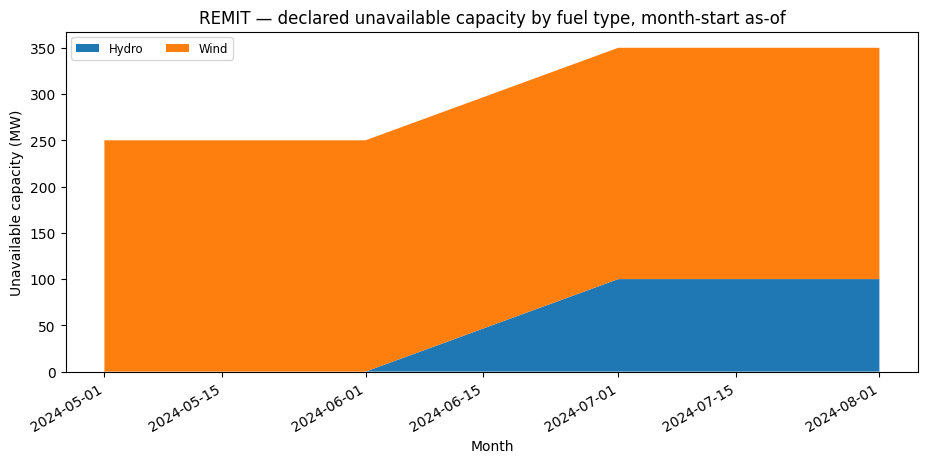

In [3]:
# T5 Cell 5 — Stacked-area chart of monthly unavailable MW by fuel type.
if monthly_long.empty:
    print("No active events in any sampled month — nothing to plot.")
else:
    pivot = monthly_long.pivot_table(
        index="month",
        columns="fuel_type",
        values="total_mw",
        aggfunc="sum",
        fill_value=0.0,
    ).sort_index()
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.stackplot(pivot.index.to_pydatetime(), pivot.T.to_numpy(), labels=pivot.columns)
    ax.set_title("REMIT — declared unavailable capacity by fuel type, month-start as-of")
    ax.set_xlabel("Month")
    ax.set_ylabel("Unavailable capacity (MW)")
    ax.legend(loc="upper left", fontsize="small", ncol=2)
    fig.autofmt_xdate()
    plt.show()

## What's next

Stage 14 reads the ``message_description`` free-text field on this
parquet and extracts structured fields with an LLM.  Stage 16 joins
the bi-temporal frame into the modelling feature table — the
``as_of`` mechanic above is exactly what guarantees the join uses
only information available at training time, no leakage.
